# MONTHLY MEAN AIR TEMPERATURE FORECATING

---
## 1. Import Libraries

In [112]:
!pip install pmdarima

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet
import pmdarima as pm

from keras.models import Sequential
from sklearn.model_selection import TimeSeriesSplit
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [114]:
from warnings import filterwarnings
filterwarnings('ignore')

---
## 2. Mount Drive

In [115]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 3. Load Dataset

- `month` → timestamp

- `mean_temp` → monthly average temperature

In [116]:
df = pd.read_csv("/content/drive/MyDrive/AI Projects/Air Temperature/surface-air-temperature-monthly-mean.csv")

df['month'] = pd.to_datetime(df['month'])
df.set_index('month', inplace=True)
df = df.sort_index()
df.head()


,mean_temp
month,
1982-01-01,25.9
1982-02-01,27.1
1982-03-01,27.2
1982-04-01,27.0
1982-05-01,28.0


In [117]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 462 entries, 1982-01-01 to 2020-06-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mean_temp  462 non-null    float64
dtypes: float64(1)
memory usage: 7.2 KB
None


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Summary

In [118]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean_temp,462.0,27.665152,0.808186,25.4,27.1,27.7,28.3,29.5


In [119]:
df.isnull().sum()

,0
mean_temp,0


### 4.2 Temperature Trend

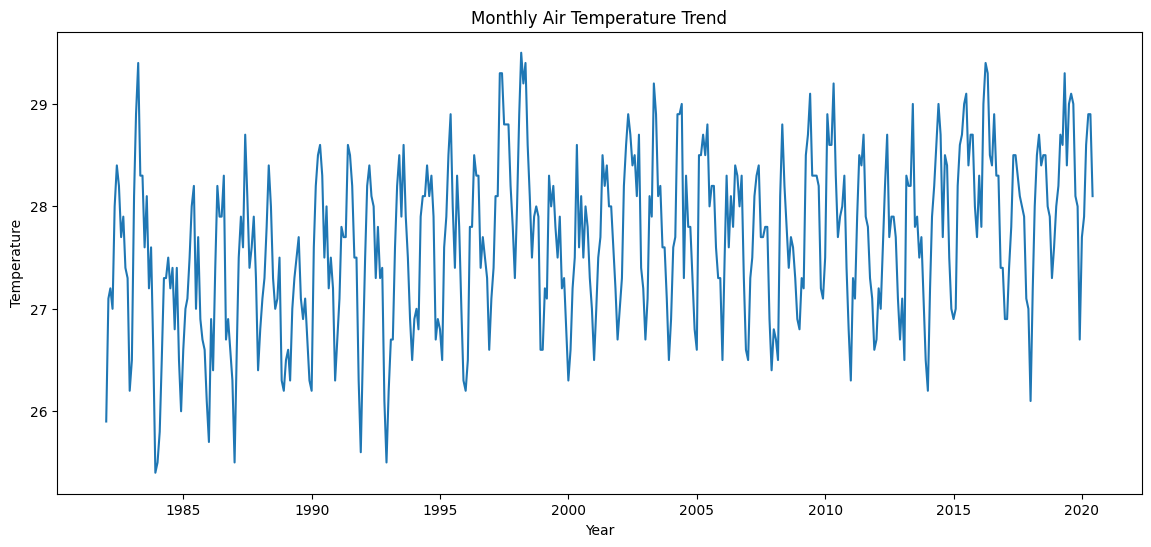

In [120]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['mean_temp'])
plt.title("Monthly Air Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

### 4.3 Rolling Mean and Variance

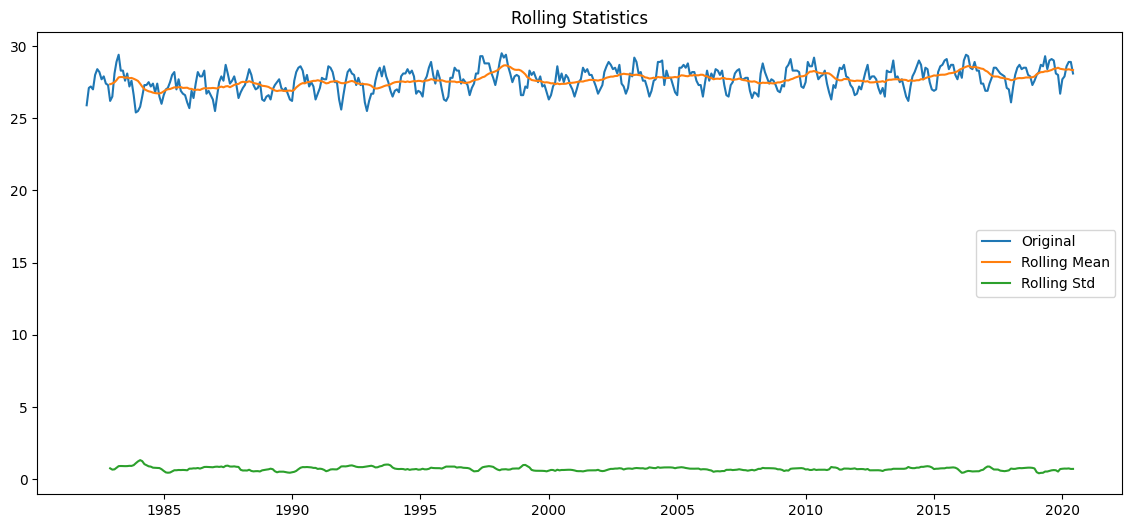

In [121]:
rolling_mean = df['mean_temp'].rolling(window=12).mean()
rolling_std = df['mean_temp'].rolling(window=12).std()

plt.figure(figsize=(14,6))
plt.plot(df['mean_temp'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title("Rolling Statistics")
plt.show()

### 4.4 Seasonal Decomposition

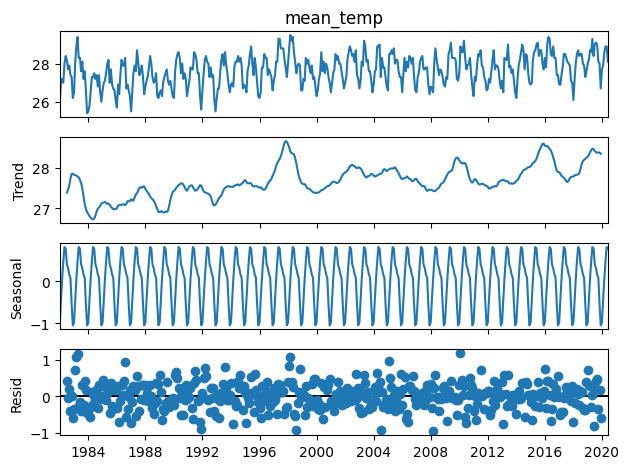

In [122]:
decomposition = seasonal_decompose(df['mean_temp'], model='additive', period=12)

decomposition.plot()
plt.show()

### 4.5 Distribution Plot

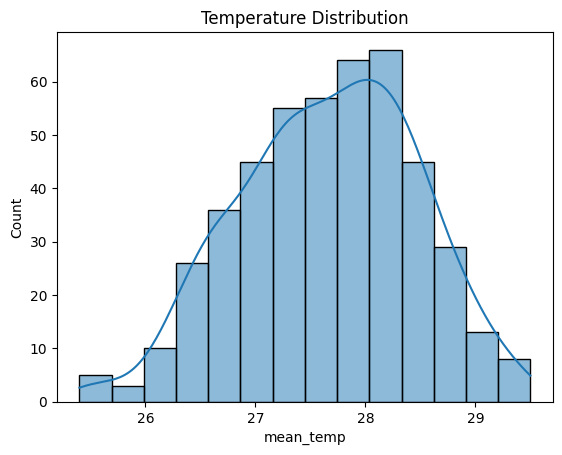

In [123]:
sns.histplot(df['mean_temp'], kde=True)
plt.title("Temperature Distribution")
plt.show()

### 4.6 Boxplot by Month

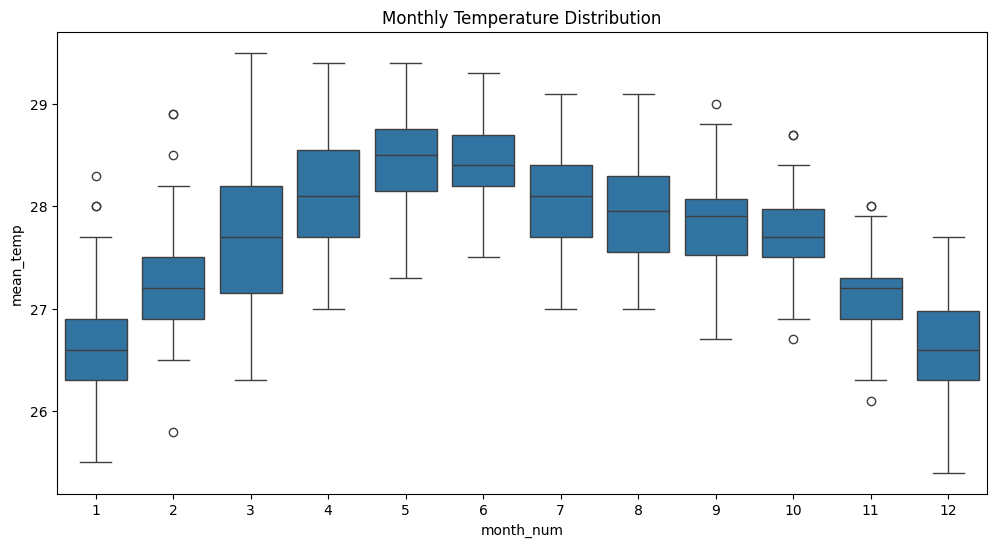

In [124]:
df['month_num'] = df.index.month

plt.figure(figsize=(12,6))
sns.boxplot(x=df['month_num'], y=df['mean_temp'])
plt.title("Monthly Temperature Distribution")
plt.show()

---
## 5. Stationarity Test (ADF)
If __p-value__ > 0.05 → data is __non-stationary__.

In [125]:
def check_stationarity(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

check_stationarity(df['mean_temp'])

ADF Statistic: -4.265046395360642
p-value: 0.0005103681123778921


---
## 6. ACF & PACF
Used to determine __ARIMA parameters__.

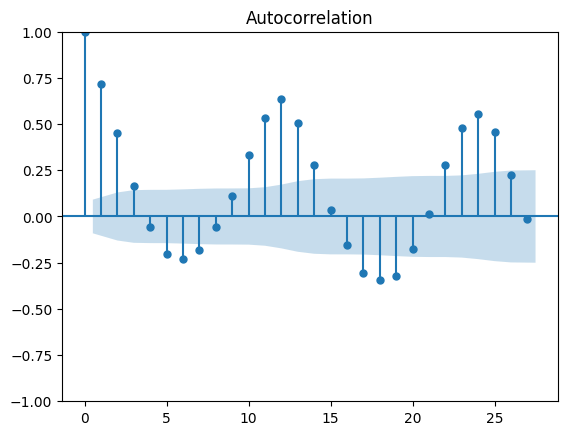

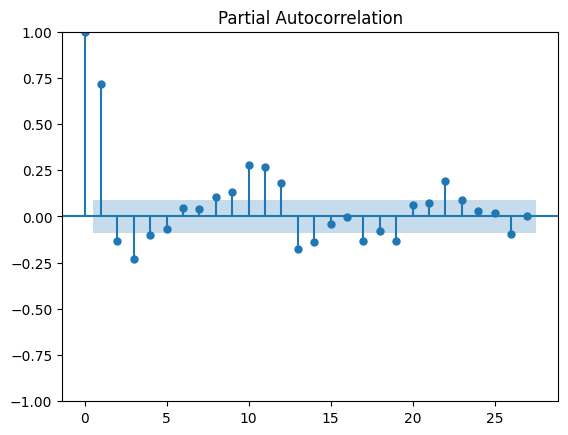

In [126]:
plot_acf(df['mean_temp'])
plt.show()

plot_pacf(df['mean_temp'])
plt.show()

---
## 7. Feature Engineering

In [127]:
df_dl = df.copy()

df_dl['month'] = df_dl.index.month
df_dl['month_sin'] = np.sin(2*np.pi*df_dl['month']/12)
df_dl['month_cos'] = np.cos(2*np.pi*df_dl['month']/12)
df_dl.columns

Index(['mean_temp', 'month_num', 'month', 'month_sin', 'month_cos'], dtype='object')

---
## 8. SCALING (ONLY FOR LSTM)

In [128]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_dl[['mean_temp','month_sin','month_cos']])

---
## 9. Train Test Split
Forecast next 24 months.

In [129]:
train_size = int(len(df) * 0.8)

train_scaled = scaled_data[:train_size]
test_scaled = scaled_data[train_size:]

train_raw = df[['mean_temp']].values[:train_size]
test_raw = df[['mean_temp']].values[train_size:]

---
## 10. CREATE DATASET FUNCTIONS


In [130]:
def create_dataset(data, time_step=12):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 12

# LSTM data
X_train, y_train = create_dataset(train_scaled, time_step)
X_test, y_test = create_dataset(test_scaled, time_step)

# ML data (flattened)
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

---
## 11. Model Building
Models used are:
- ARIMA
- SARIMA (Seasonal)
- Facebook Prophet (Transfer Learning Style)
- Random Forest
- XGBoost
- LSTM (Deep Learning)

---
### Model 1 — ARIMA

In [144]:
arima_auto = pm.auto_arima(
    train_raw.flatten(),
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=False
)

arima_pred = arima_auto.predict(n_periods=len(test_raw))

arima_rmse = np.sqrt(
    mean_squared_error(test_raw.flatten(), arima_pred)
)

---
### Model 2 — SARIMA (Seasonal)

In [132]:
sarima_auto = pm.auto_arima(
    train_raw.flatten(),
    seasonal=True,
    m=12,  # monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print(sarima_auto.summary())

sarima_pred = sarima_auto.predict(n_periods=len(test_raw))

sarima_rmse = np.sqrt(
    mean_squared_error(test_raw.flatten(), sarima_pred)
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.47 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=676.539, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=585.287, Time=0.19 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=620.569, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=674.569, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=678.527, Time=0.04 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=564.327, Time=0.52 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=3.98 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=2.56 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=587.187, Time=0.38 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=558.666, Time=0.78 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=585.109, Time=0.28 sec
 ARIMA(2,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=3.68 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=1.25 sec
 ARIMA(3,1,0)(2,0,0)[12] intercept   : AIC=558.563, T

---
### Model 3 — Facebook Prophet (Transfer Learning Style)

In [133]:
df_prophet = df.reset_index()[['month', 'mean_temp']]
df_prophet.columns = ['ds', 'y']

df_train_prophet = df_prophet.iloc[:train_size]
df_test_prophet = df_prophet.iloc[train_size:]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(df_train_prophet)

future = prophet_model.make_future_dataframe(
    periods=len(df_test_prophet),
    freq='M'
)

forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'][-len(df_test_prophet):].values

prophet_rmse = np.sqrt(
    mean_squared_error(df_test_prophet['y'].values, prophet_pred)
)

---
### Model 4 — Random Forest

In [134]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train_rf, y_train)
rf_pred = rf_model.predict(X_test_rf)

rf_pred = scaler.inverse_transform(
    np.concatenate([rf_pred.reshape(-1,1), np.zeros((rf_pred.shape[0],2))], axis=1)
)[:,0]

y_test_actual = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1,1), np.zeros((y_test.shape[0],2))], axis=1)
)[:,0]

rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_pred))

---
### Model 5 — XGBoost

In [135]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_rf, y_train)
xgb_pred = xgb_model.predict(X_test_rf)

xgb_pred = scaler.inverse_transform(
    np.concatenate([xgb_pred.reshape(-1,1), np.zeros((xgb_pred.shape[0],2))], axis=1)
)[:,0]

xgb_rmse = np.sqrt(mean_squared_error(y_test_actual, xgb_pred))

---
### Model 6 — LSTM Deep Learning

In [136]:
lstm_model = Sequential()

lstm_model.add(LSTM(128, return_sequences=True, input_shape=(time_step, 3)))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(64))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [137]:
lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

lstm_pred = lstm_model.predict(X_test)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0617 - val_loss: 0.0194
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0260 - val_loss: 0.0502
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0231 - val_loss: 0.0149
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0196 - val_loss: 0.0183
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0208 - val_loss: 0.0146
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0193 - val_loss: 0.0245
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0179 - val_loss: 0.0250
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0178 - val_loss: 0.0126
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0189 - val_loss: 0.0265
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0169 - val_loss: 0.0123
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0184 - val_loss: 0.0185
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step


In [138]:
# inverse scaling (only Mean_temp column)
lstm_pred = scaler.inverse_transform(
    np.concatenate([lstm_pred, np.zeros((lstm_pred.shape[0],2))], axis=1)
)[:,0]

y_test_actual = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1,1), np.zeros((y_test.shape[0],2))], axis=1)
)[:,0]

lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

---
## 12. Model Comparison

In [145]:
results = pd.DataFrame({

"Model":[
"ARIMA",
"SARIMA",
"Prophet",
"Random Forest",
"XGBoost",
"LSTM"
],

"RMSE":[
arima_rmse,
sarima_rmse,
prophet_rmse,
rf_rmse,
xgb_rmse,
lstm_rmse
]

})

print(results)

           Model      RMSE
0          ARIMA  0.757149
1         SARIMA  0.686390
2        Prophet  0.661710
3  Random Forest  0.441854
4        XGBoost  0.457088
5           LSTM  0.398398


---
## 13. Comparison Visualization

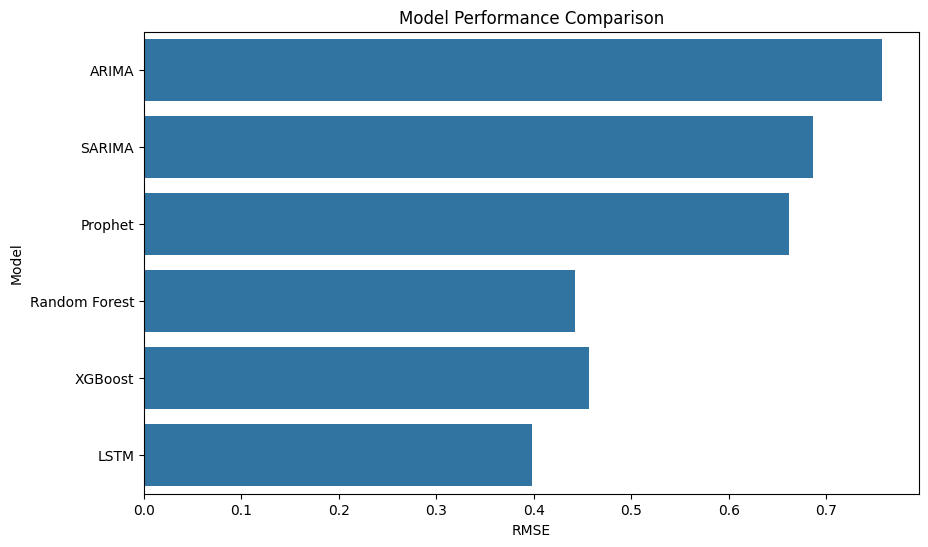

In [140]:
plt.figure(figsize=(10,6))

sns.barplot(x="RMSE", y="Model", data=results)

plt.title("Model Performance Comparison")
plt.show()

---
## 14. Forecast Visualization

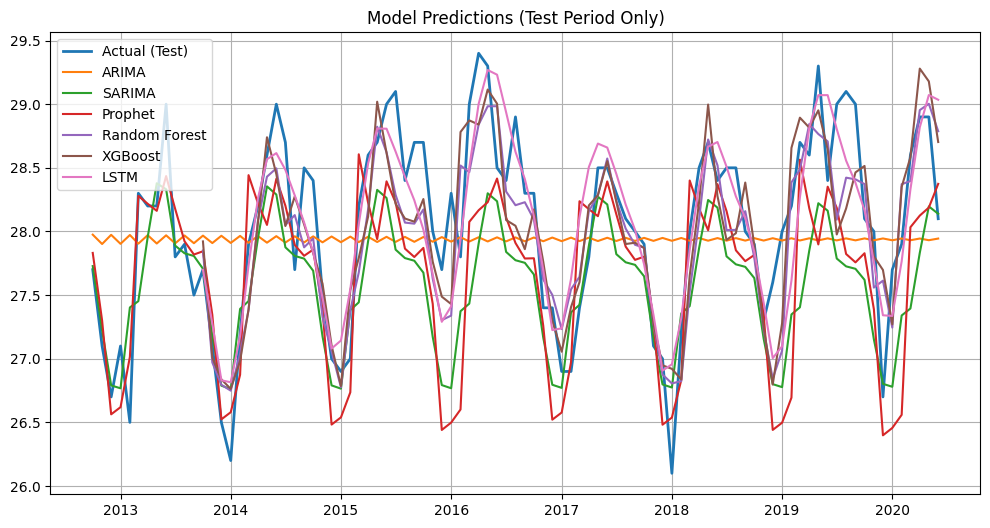

In [141]:
test = df.iloc[train_size:]

plt.figure(figsize=(12,6))

plt.plot(test.index, df['mean_temp'][-len(test):], label="Actual (Test)", linewidth=2)

plt.plot(test.index, arima_pred, label="ARIMA")
plt.plot(test.index, sarima_pred, label="SARIMA")
plt.plot(test.index, prophet_pred, label="Prophet")

plt.plot(test.index[time_step:], rf_pred, label="Random Forest")
plt.plot(test.index[time_step:], xgb_pred, label="XGBoost")
plt.plot(test.index[time_step:], lstm_pred, label="LSTM")

plt.title("Model Predictions (Test Period Only)")
plt.legend()
plt.grid()
plt.show()



---

#  **15. Conclusion**

This project focused on forecasting monthly mean air temperature using a combination of **statistical, machine learning, and deep learning models**. Multiple approaches were implemented and evaluated to identify the most effective model for capturing temporal patterns, seasonality, and trends in the data.

---

##  **16. Model Performance Summary**

| Model         | RMSE      |
| ------------- | --------- |
| ARIMA         | 0.757     |
| SARIMA        | 0.686     |
| Prophet       | 0.662     |
| Random Forest | 0.442     |
| XGBoost       | 0.457     |
| **LSTM**      | **0.398** |

---

## **17. Key Observations**

* **LSTM achieved the best performance (RMSE: 0.398)**
  → Effectively captured **temporal dependencies, non-linearity, and seasonal patterns** using sequence learning and feature engineering.

* **Random Forest and XGBoost performed strongly**
  → Benefited from **lag features and engineered variables**, showing that tree-based models can handle time series when converted into supervised learning format.

* **Prophet performed better than ARIMA/SARIMA**
  → Due to its built-in **trend and seasonality modeling**, but limited in capturing complex fluctuations.

* **SARIMA outperformed ARIMA**
  → Demonstrates the importance of **seasonal components (monthly cycles)** in temperature data.

* **ARIMA showed the weakest performance**
  → Indicates that **simple linear models struggle with complex seasonal and nonlinear patterns**.

---

## **18. Final Conclusion**

> The study demonstrates that **deep learning models, particularly LSTM, are the most effective for time series forecasting of air temperature**, as they can capture both short-term fluctuations and long-term seasonal patterns.

However, **machine learning models like Random Forest and XGBoost provide competitive performance with lower complexity**, making them practical alternatives in resource-constrained environments.

Traditional statistical models such as ARIMA and SARIMA, while interpretable, are less effective for complex real-world data with non-linear dynamics.

---
